In [3]:
pip install torchvision

  Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl (4.3 MB)
Using cached torch-2.11.0-cp313-cp313-win_amd64.whl (114.6 MB)

  Attempting uninstall: torch

    Found existing installation: torch 2.9.0

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ------------------------

  You can safely remove it manually.


In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
import torch

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from image_baseline_utils import (
    load_image_splits,
    print_split_summary,
    build_dataloaders,
    build_model,
    make_loss_fn,
    fit_model,
    run_test_evaluation,
)

processed_dir = project_root / "data" / "processed"
results_dir = project_root / "results" / "image_baseline_resnet18"
results_dir.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [2]:
train_csv = processed_dir / "image_train_group_test.csv"
val_csv = processed_dir / "image_val_group_test.csv"
test_csv = processed_dir / "image_test_group_test.csv"

print(train_csv)
print(val_csv)
print(test_csv)

c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\image_train_group_test.csv
c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\image_val_group_test.csv
c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\image_test_group_test.csv


In [3]:
splits = load_image_splits(
    train_csv=train_csv,
    val_csv=val_csv,
    test_csv=test_csv,
)

print_split_summary(
    train_df=splits.train_df,
    val_df=splits.val_df,
    test_df=splits.test_df,
)


TRAIN
Rows: 7182
Groups: 953
image_class
forged       3731
bona_fide    3451
Name: count, dtype: int64
image_class
forged       51.95
bona_fide    48.05
Name: proportion, dtype: float64

VAL
Rows: 1508
Groups: 204
image_class
forged       765
bona_fide    743
Name: count, dtype: int64
image_class
forged       50.73
bona_fide    49.27
Name: proportion, dtype: float64

TEST
Rows: 1474
Groups: 205
image_class
bona_fide    739
forged       735
Name: count, dtype: int64
image_class
bona_fide    50.14
forged       49.86
Name: proportion, dtype: float64

GROUP OVERLAP
train_val_overlap: 0
train_test_overlap: 0
val_test_overlap: 0


In [4]:
batch_size = 32

train_loader, val_loader, test_loader = build_dataloaders(
    splits=splits,
    batch_size=batch_size,
    num_workers=0,
)

In [5]:
model = build_model(pretrained=True, freeze_backbone=False).to(device)

loss_fn = make_loss_fn(splits.train_df, device=device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
model_save_path = results_dir / "best_resnet18_image_baseline.pt"

model, history_df = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    epochs=10,
    threshold=0.5,
    early_stopping_patience=3,
    model_save_path=model_save_path,
)

history_df

Epoch 01 | train_loss=0.2102 | val_loss=0.1824 | val_f1=0.9134 | val_roc_auc=0.9681
Epoch 02 | train_loss=0.1827 | val_loss=0.1751 | val_f1=0.9227 | val_roc_auc=0.9737
Epoch 03 | train_loss=0.1725 | val_loss=0.1564 | val_f1=0.9272 | val_roc_auc=0.9830
Epoch 04 | train_loss=0.1474 | val_loss=0.1586 | val_f1=0.8991 | val_roc_auc=0.9882
Epoch 05 | train_loss=0.1068 | val_loss=0.0875 | val_f1=0.9605 | val_roc_auc=0.9948
Epoch 06 | train_loss=0.0793 | val_loss=0.0910 | val_f1=0.9550 | val_roc_auc=0.9950
Epoch 07 | train_loss=0.0603 | val_loss=0.1166 | val_f1=0.9383 | val_roc_auc=0.9927
Epoch 08 | train_loss=0.0521 | val_loss=0.0776 | val_f1=0.9640 | val_roc_auc=0.9960
Epoch 09 | train_loss=0.0416 | val_loss=0.1038 | val_f1=0.9605 | val_roc_auc=0.9966
Epoch 10 | train_loss=0.0390 | val_loss=0.0907 | val_f1=0.9599 | val_roc_auc=0.9959


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.210198,0.182361,0.907825,0.872619,0.958170,0.913396,0.968057
1,2,0.182668,0.175133,0.917772,0.882002,0.967320,0.922693,0.973668
2,3,0.172542,0.156379,0.921751,0.878363,0.981699,0.927160,0.982957
3,4,0.147385,0.158627,0.905172,0.976994,0.832680,0.899083,0.988179
4,5,0.106819,0.087494,0.960212,0.966887,0.954248,0.960526,0.994819
5,6,0.079260,0.091034,0.955570,0.982044,0.929412,0.955003,0.994961
6,7,0.060254,0.116590,0.939655,0.974648,0.904575,0.938305,0.992693
7,8,0.052110,0.077604,0.963528,0.964660,0.963399,0.964029,0.995978
8,9,0.041584,0.103844,0.958886,0.936646,0.985621,0.960510,0.996606
9,10,0.039044,0.090672,0.960212,0.982216,0.938562,0.959893,0.995929


In [10]:
test_metrics = run_test_evaluation(
    model=model,
    test_loader=test_loader,
    loss_fn=loss_fn,
    device=device,
    threshold=0.5,
)

test_metrics


TEST METRICS
loss: 0.0603
accuracy: 0.9735
precision: 0.9860
recall: 0.9605
f1: 0.9731
roc_auc: 0.9975
confusion_matrix:
[[729  10]
 [ 29 706]]


{'threshold': 0.5,
 'accuracy': 0.9735413839891451,
 'precision': 0.9860335195530726,
 'recall': 0.9605442176870749,
 'f1': 0.9731219848380427,
 'confusion_matrix': [[729, 10], [29, 706]],
 'roc_auc': 0.9974538123774545,
 'loss': 0.06027849964799708}

In [11]:
history_path = results_dir / "training_history.csv"
metrics_path = results_dir / "test_metrics.json"

history_df.to_csv(history_path, index=False)

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)

print("Saved:", history_path)
print("Saved:", metrics_path)
print("Saved:", model_save_path)

Saved: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\image_baseline_resnet18\training_history.csv
Saved: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\image_baseline_resnet18\test_metrics.json
Saved: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\image_baseline_resnet18\best_resnet18_image_baseline.pt


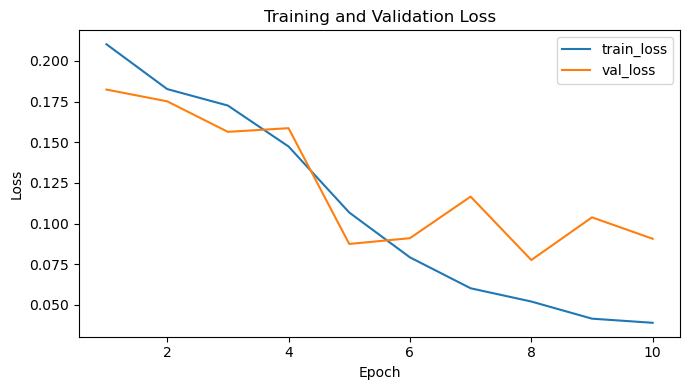

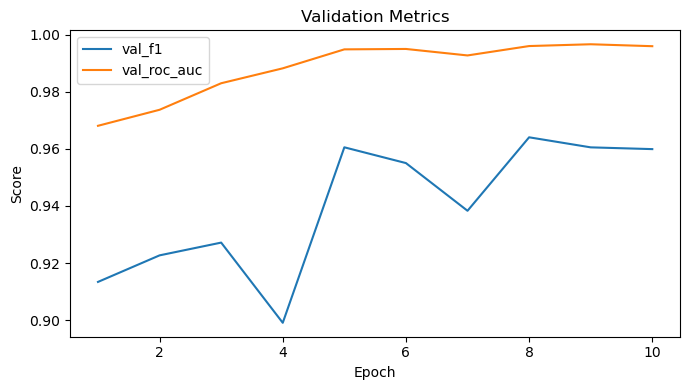

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["val_f1"], label="val_f1")
plt.plot(history_df["epoch"], history_df["val_roc_auc"], label="val_roc_auc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
best_epoch_row = history_df.loc[history_df["val_f1"].idxmax()].copy()
best_epoch_row

epoch            8.000000
train_loss       0.052110
val_loss         0.077604
val_accuracy     0.963528
val_precision    0.964660
val_recall       0.963399
val_f1           0.964029
val_roc_auc      0.995978
Name: 7, dtype: float64

In [14]:
best_epoch_path = results_dir / "best_epoch_by_val_f1.csv"
best_epoch_row.to_frame().T.to_csv(best_epoch_path, index=False)
print("Saved:", best_epoch_path)

Saved: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\image_baseline_resnet18\best_epoch_by_val_f1.csv


In [15]:
from image_baseline_utils import predict_probs, compute_metrics

In [16]:
y_true_test, y_prob_test = predict_probs(model, test_loader, device)

test_pred_df = splits.test_df.reset_index(drop=True).copy()
assert len(test_pred_df) == len(y_true_test)

test_pred_df["y_true"] = y_true_test
test_pred_df["y_prob"] = y_prob_test
test_pred_df["y_pred"] = (test_pred_df["y_prob"] >= 0.5).astype(int)

test_pred_df.head()

KeyboardInterrupt: 

In [ ]:
test_pred_path = results_dir / "test_predictions.csv"
test_pred_df.to_csv(test_pred_path, index=False)
print("Saved:", test_pred_path)

In [ ]:
import numpy as np
import pandas as pd

def subgroup_metrics(df: pd.DataFrame, group_col: str, threshold: float = 0.5) -> pd.DataFrame:
    rows = []

    work = df.copy()
    work[group_col] = work[group_col].fillna("missing").astype(str)

    for group_value, g in work.groupby(group_col, dropna=False):
        y_true = g["y_true"].to_numpy()
        y_prob = g["y_prob"].to_numpy()

        metrics = compute_metrics(y_true, y_prob, threshold=threshold)

        rows.append({
            group_col: group_value,
            "n_rows": len(g),
            "n_neg": int((y_true == 0).sum()),
            "n_pos": int((y_true == 1).sum()),
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
        })

    out = pd.DataFrame(rows).sort_values("n_rows", ascending=False).reset_index(drop=True)
    return out

In [ ]:
source_type_metrics = subgroup_metrics(test_pred_df, "source_type", threshold=0.5)
source_type_metrics

In [ ]:
doc_type_metrics = subgroup_metrics(test_pred_df, "doc_type", threshold=0.5)
doc_type_metrics

In [ ]:
source_dataset_metrics = subgroup_metrics(test_pred_df, "source_dataset", threshold=0.5)
source_dataset_metrics

In [ ]:
source_type_metrics.to_csv(results_dir / "test_metrics_by_source_type.csv", index=False)
doc_type_metrics.to_csv(results_dir / "test_metrics_by_doc_type.csv", index=False)
source_dataset_metrics.to_csv(results_dir / "test_metrics_by_source_dataset.csv", index=False)

In [ ]:
fantasy_test = test_pred_df[test_pred_df["source_dataset"] == "fantasyid"].copy()
fantasy_only_metrics = compute_metrics(
    fantasy_test["y_true"].to_numpy(),
    fantasy_test["y_prob"].to_numpy(),
    threshold=0.5,
)
fantasy_only_metrics

In [ ]:
import random
import numpy as np
import torch

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [ ]:
seed_list = [42, 52, 62]
seed_results = []

for seed in seed_list:
    print("\n" + "=" * 70)
    print(f"RUNNING SEED {seed}")
    print("=" * 70)

    set_seed(seed)

    train_loader, val_loader, test_loader = build_dataloaders(
        splits=splits,
        batch_size=batch_size,
        num_workers=0,
    )

    model = build_model(pretrained=True, freeze_backbone=False).to(device)

    loss_fn = make_loss_fn(splits.train_df, device=device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4,
    )

    seed_model_path = results_dir / f"best_resnet18_seed_{seed}.pt"

    model, seed_history_df = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
        epochs=10,
        threshold=0.5,
        early_stopping_patience=3,
        model_save_path=seed_model_path,
    )

    seed_test_metrics = run_test_evaluation(
        model=model,
        test_loader=test_loader,
        loss_fn=loss_fn,
        device=device,
        threshold=0.5,
    )

    best_epoch_row = seed_history_df.loc[seed_history_df["val_f1"].idxmax()]

    seed_results.append({
        "seed": seed,
        "best_epoch": int(best_epoch_row["epoch"]),
        "best_val_f1": float(best_epoch_row["val_f1"]),
        "best_val_roc_auc": float(best_epoch_row["val_roc_auc"]),
        "test_accuracy": float(seed_test_metrics["accuracy"]),
        "test_precision": float(seed_test_metrics["precision"]),
        "test_recall": float(seed_test_metrics["recall"]),
        "test_f1": float(seed_test_metrics["f1"]),
        "test_roc_auc": float(seed_test_metrics["roc_auc"]),
    })

In [17]:
seed_results_df = pd.DataFrame(seed_results)
seed_results_df

NameError: name 'seed_results' is not defined

In [ ]:
seed_summary = seed_results_df.agg({
    "test_accuracy": ["mean", "std"],
    "test_precision": ["mean", "std"],
    "test_recall": ["mean", "std"],
    "test_f1": ["mean", "std"],
    "test_roc_auc": ["mean", "std"],
}).round(4)

seed_summary

In [ ]:
seed_results_df.to_csv(results_dir / "seed_results.csv", index=False)
seed_summary.to_csv(results_dir / "seed_results_summary.csv")